In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray

In [2]:
cluster = LocalCluster(n_workers=6, memory_limit='32GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 66,Total memory: 192.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38995,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:32783,Total threads: 11
Dashboard: http://127.0.0.1:45809/status,Memory: 32.00 GiB
Nanny: tcp://127.0.0.1:44565,


In [3]:
run_id = 'dbq0er2m'
ds_attr= xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc')
ds_cycs = xr.open_dataset('/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/cyclones_centers.nc')[['lon','lat']].reindex(time_of_event=ds_attr.time_of_event).isel(timestep_past=slice(-8*7,None))

In [4]:
ds_attr.predictions.min('timestep_past').to_series().sort_values()

time_of_event
2002-10-24    0.083027
2006-11-25    0.152228
2002-01-01    0.153756
2003-01-25    0.156088
2012-05-13    0.157958
                ...   
2005-01-06    0.814589
2005-01-08    0.817038
2005-01-05    0.821384
2005-01-07    0.822393
2005-01-10    0.823529
Name: predictions, Length: 234, dtype: float32

In [5]:
ds_zarr = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024_equalarea.zarr")
data_plot = (ds_attr.features*ds_zarr.data_std_global + ds_zarr.data_mean).load()
# dist.sel(time_of_event='2007-01-09').plot.contour(col='timestep_past', levels=[1000], colors='.4')

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 249.95 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [4]:
data_plot.sel(var_name='msl').sel(time_of_event='2005-01-04').isel(timestep_past=4).plot(robust=True)

NameError: name 'data_plot' is not defined

In [6]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()
# cycs

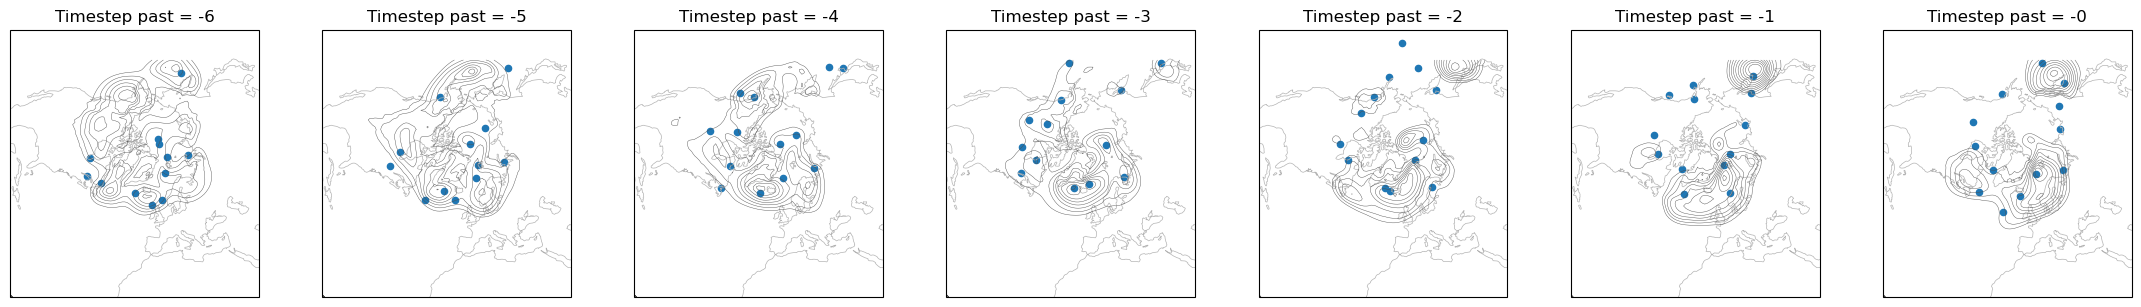

In [10]:
plot = data_plot.sel(var_name='msl').sel(time_of_event='2007-01-09').plot.contour(col='timestep_past', levels=np.arange(96000,101000,500), subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), transform=ccrs.NorthPolarStereo(0,90), colors='.3',linewidths=.3)
for k, ax in enumerate(plot.axs.flatten()):
    # dist.sel(time_of_event='2007-01-09').isel(timestep_past=k).plot.contour(ax=ax, levels=[1000])
    cycs.set_index('date').loc[f'2007-01-{9-k}'].query("msl<100000").groupby('track_id').mean().plot.scatter(x='lon', y='lat', transform=ccrs.PlateCarree(),ax=ax)
    ax.set_title(f'Timestep past = -{6-k}')
    ax.coastlines(color='.7', lw=.5)

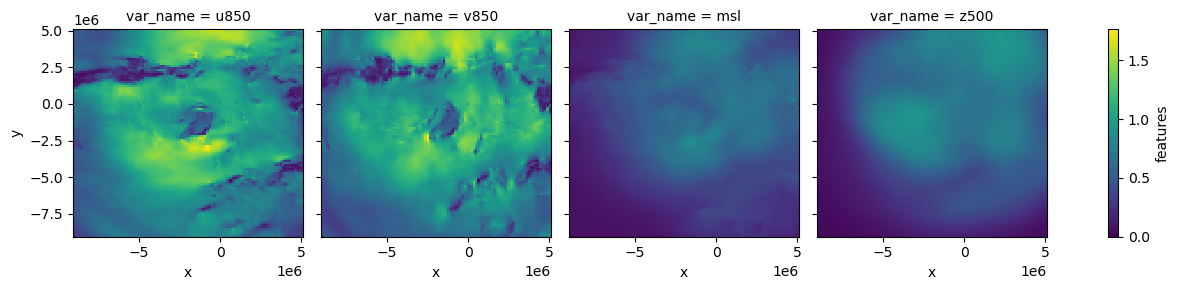

In [14]:
ds_attr.features.isel(timestep_past=-1).std('time_of_event').plot(col='var_name')

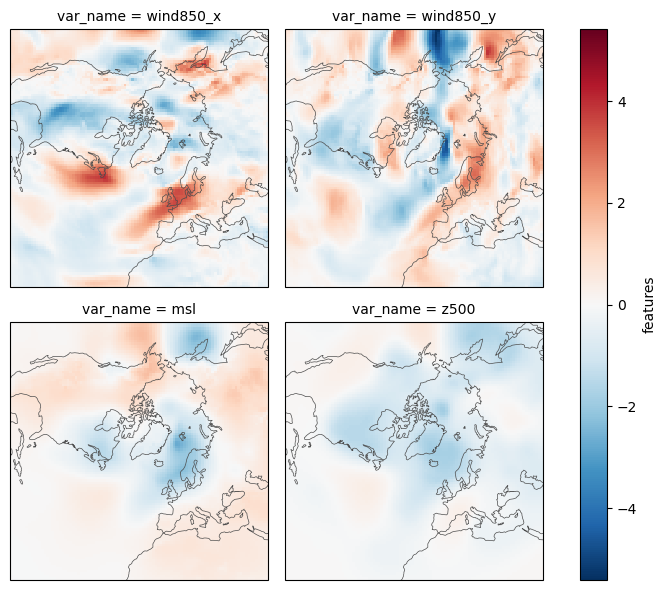

In [7]:
ds_ = ds_attr.sel(time_of_event='2007-01-09').features.isel(timestep_past=-1).assign_coords(var_name=['wind850_x','wind850_y','msl','z500'])
# ds_ = ds_/ds_.quantile(1,['x','y'])
plot = ds_.plot( col='var_name',col_wrap=2, subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), transform=ccrs.NorthPolarStereo(0,90), aspect=1.1)
for k, ax in enumerate(plot.axs.flatten()):
    # dist.sel(time_of_event='2007-01-09').isel(timestep_past=k%7).plot.contour(ax=ax, levels=[1000], colors='C3',  transform=ccrs.NorthPolarStereo(0,90))
    # data_plot.sel(var_name='msl').sel(time_of_event='2007-01-09').isel(timestep_past=k%7).plot.contour(levels=np.arange(96000,101000,500), transform=ccrs.NorthPolarStereo(0,90), colors='.4',linewidths=.3, ax=ax)
    # ax.set_title(f'Timestep past = -{6-k%7}')
    ax.coastlines(color='.3', lw=.5)


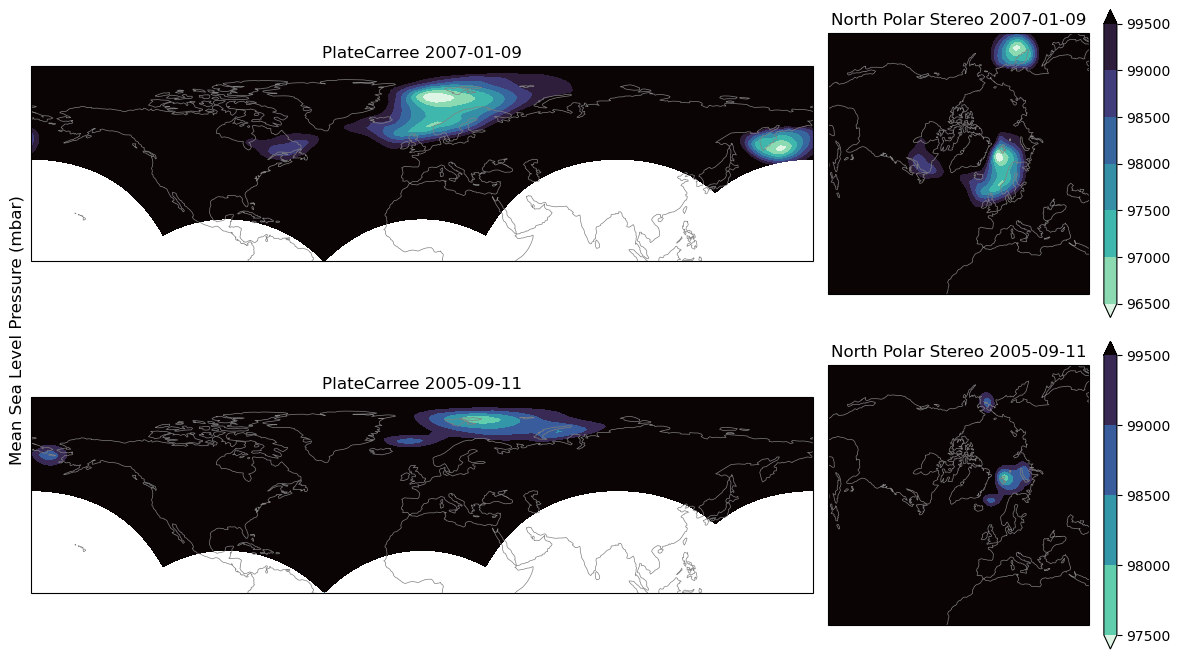

In [59]:
fig, axs = plt.subplot_mosaic("""
                              ABC
                              DEF
                              """,
                              per_subplot_kw=dict(AD=dict(projection=ccrs.PlateCarree()),
                                                  BE=dict(projection=ccrs.NorthPolarStereo(0,90))),
                                                  width_ratios=[3,1,0.05],
                                                  figsize=(12,7))

data_plot.sel(time_of_event='2007-01-09', var_name='msl').isel(timestep_past=0).plot.contourf(levels=np.arange(96500,100000,500), extend='both', cmap='mako_r', ax=axs['A'], transform=ccrs.NorthPolarStereo(0,90), cbar_ax=axs['C'])
data_plot.sel(time_of_event='2007-01-09', var_name='msl').isel(timestep_past=0).plot.contourf(levels=np.arange(96500,100000,500), extend='both', cmap='mako_r', ax=axs['B'], transform=ccrs.NorthPolarStereo(0,90), cbar_ax=axs['C'])
# data_plot.sel(time_of_event='2008-01-18').sel(var_name='msl').sel(timestep=-2)
data_plot.sel(time_of_event='2005-09-14', var_name='msl').isel(timestep_past=-4).plot.contourf(levels=np.arange(97500,100000,500), extend='both', cmap='mako_r', ax=axs['D'], transform=ccrs.NorthPolarStereo(0,90), cbar_ax=axs['F'])
data_plot.sel(time_of_event='2005-09-14', var_name='msl').isel(timestep_past=-4).plot.contourf(levels=np.arange(97500,100000,500), extend='both', cmap='mako_r', ax=axs['E'], transform=ccrs.NorthPolarStereo(0,90), cbar_ax=axs['F'])

axs['A'].coastlines(color='.5', lw=.5)
axs['B'].coastlines(color='.5', lw=.5)
axs['D'].coastlines(color='.5', lw=.5)
axs['E'].coastlines(color='.5', lw=.5)
axs['A'].set_title('PlateCarree 2007-01-09')
axs['B'].set_title('North Polar Stereo 2007-01-09')
axs['D'].set_title('PlateCarree 2005-09-11')
axs['E'].set_title('North Polar Stereo 2005-09-11')
fig.supylabel('Mean Sea Level Pressure (mbar)')
plt.tight_layout()

In [16]:
ds_attr

<xarray.Dataset> Size: 786MB
Dimensions:                                (time_of_event: 234,
                                            timestep_past: 7, var_name: 4,
                                            y: 100, x: 100)
Coordinates:
  * x                                      (x) float64 800B -9e+06 ... 5.031e+06
  * y                                      (y) float64 800B -9e+06 ... 5.031e+06
  * var_name                               (var_name) <U4 64B 'u850' ... 'z500'
  * time_of_event                          (time_of_event) datetime64[ns] 2kB ...
  * timestep_past                          (timestep_past) int64 56B -6 -5 ... 0
    lat                                    (y, x) float64 80kB ...
    lon                                    (y, x) float64 80kB ...
Data variables:
    features                               (time_of_event, timestep_past, var_name, y, x) float32 262MB ...
    targets                                (time_of_event) float64 2kB ...
    rain                                   (time_of_event) float64 2kB ...
    predictions                            (time_of_event, timestep_past) float32 7kB ...
    attributions_ig                        (time_of_event, timestep_past, var_name, y, x) float32 262MB ...
    attributions_lrp_eps-alpha2-beta1flat  (time_of_event, timestep_past, var_name, y, x) float32 262MB ...

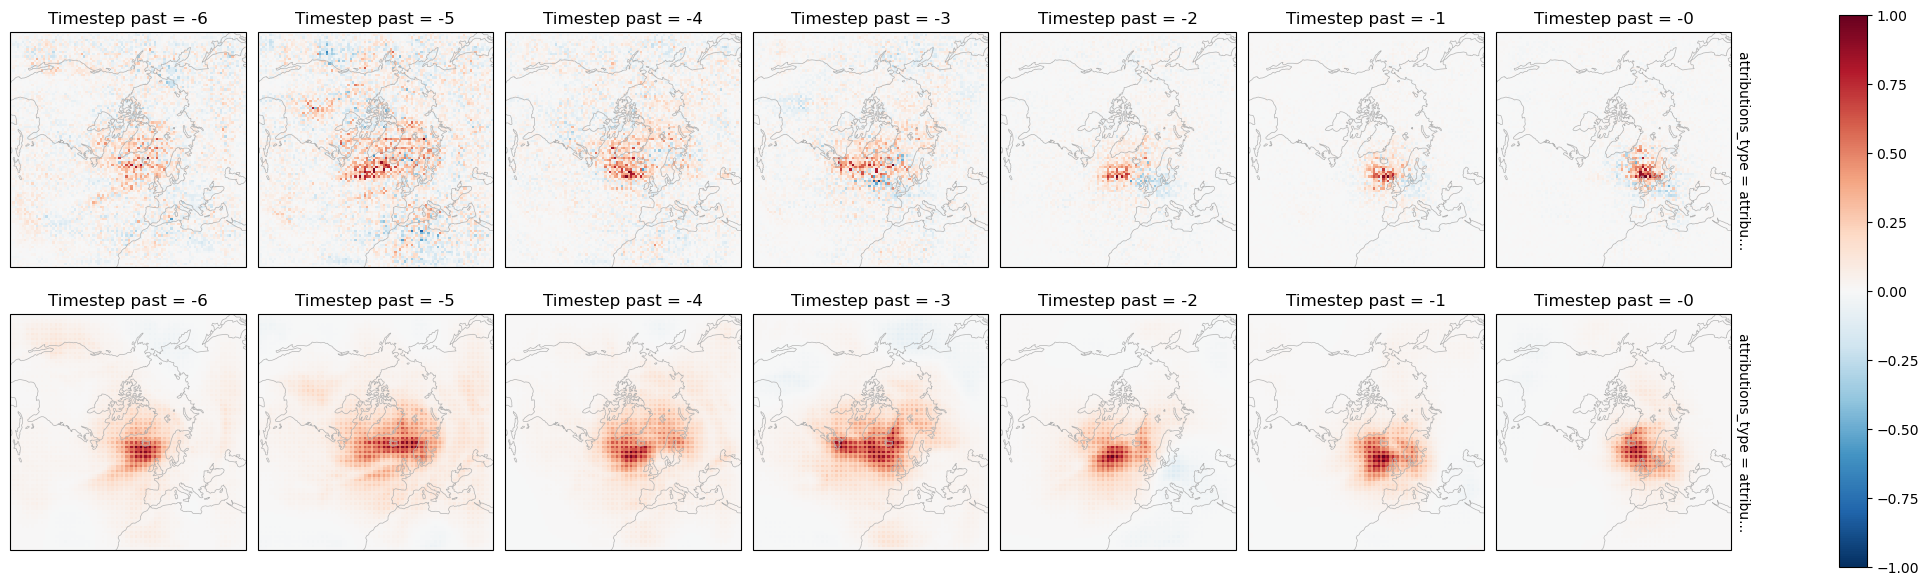

In [18]:
ds_ = ds_attr.sel(time_of_event='2005-01-04').sum('var_name')[['attributions_ig','attributions_lrp_eps-alpha2-beta1flat']].to_array('attributions_type').rolling(x=1,y=1, center=True).mean()
ds_ = ds_/ds_.quantile(1,['x','y'])
plot = ds_.plot(col='timestep_past', row='attributions_type', subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), transform=ccrs.NorthPolarStereo(0,90))
for k, ax in enumerate(plot.axs.flatten()):
    # dist.sel(time_of_event='2005-01-04').isel(timestep_past=k%7).plot.contour(ax=ax, levels=[1000], colors='C3',  transform=ccrs.NorthPolarStereo(0,90))
    # data_plot.sel(var_name='msl').sel(time_of_event='2005-01-04').isel(timestep_past=k%7).plot.contour(levels=np.arange(96000,101000,500), transform=ccrs.NorthPolarStereo(0,90), colors='.4',linewidths=.3, ax=ax)
    ax.set_title(f'Timestep past = -{6-k%7}')
    ax.coastlines(color='.7', lw=.5)

# 2004-12-31

In [ ]:
def lonlat_to_nps_xy_cartopy(
    lon_da: xr.DataArray,
    lat_da: xr.DataArray,
    central_longitude: float = 0.0,
    true_scale_latitude: float | None = 70.0,  # set None for Cartopy's default
) -> tuple[xr.DataArray, xr.DataArray]:
    """
    Project lon/lat (EPSG:4326) to meters in a North Polar Stereographic projection using Cartopy.
    Works with NumPy and dask-backed xarray DataArrays of any dimensionality (e.g., time,y,x).

    Parameters
    ----------
    lon_da, lat_da : xr.DataArray
        Longitudes and latitudes in degrees, same shape.
    central_longitude : float
        Meridian of origin for the projection (deg).
    true_scale_latitude : float | None
        Latitude of true scale (deg). Use ~70 for EPSG:3413-like scale. None -> Cartopy default.

    Returns
    -------
    x_m, y_m : xr.DataArray
        Projected coordinates (meters), same shape/dims as inputs.
    """
    if lon_da.shape != lat_da.shape:
        raise ValueError("lon_da and lat_da must have the same shape")

    geodetic = ccrs.PlateCarree()
    proj = ccrs.NorthPolarStereo(
        central_longitude=central_longitude,
        true_scale_latitude=true_scale_latitude
    )

    def _chunk_transform(lon_chunk: np.ndarray, lat_chunk: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        # Flatten -> transform -> reshape back (fast per-chunk)
        shp = lon_chunk.shape
        lon_f = lon_chunk.ravel()
        lat_f = lat_chunk.ravel()

        # Transform (returns Nx3; columns are x,y,z). z is ignored.
        pts = proj.transform_points(geodetic, lon_f, lat_f)
        x = pts[:, 0].reshape(shp)
        y = pts[:, 1].reshape(shp)
        return x, y

    x_m, y_m = xr.apply_ufunc(
        _chunk_transform,
        lon_da, lat_da,
        input_core_dims=[[], []],          # treat the whole chunk as core
        output_core_dims=[[], []],
        vectorize=False,                    # we handle array chunks, not elementwise
        dask="parallelized",               # works with dask chunks
        output_dtypes=[np.float64, np.float64]
    )

    # Carry over coords/attrs sensibly
    x_m = x_m.assign_coords(lon=lon_da.coords.get("lon", None)).rename("x_m")
    y_m = y_m.assign_coords(lat=lat_da.coords.get("lat", None)).rename("y_m")
    x_m.attrs.update(units="m", crs="NorthPolarStereo")
    y_m.attrs.update(units="m", crs="NorthPolarStereo")
    return x_m, y_m

In [30]:
distances_to_cyclone = np.hypot(ds_attr.stack(space=['y','x']).space.x - ds_cycs.chunk(time_of_event=5).x_nps,ds_attr.stack(space=['y','x']).space.y- ds_cycs.y_nps.chunk(time_of_event=5))
dist = distances_to_cyclone.min('track_number').coarsen(timestep_past=8).min().reindex(time_of_event=ds_attr.time_of_event).load().unstack('space')/1000
dist = dist.rename('distance_to_cyclone').assign_coords(timestep_past = ds_attr.timestep_past)
ds_attr['distance_to_cyclone'] = dist

AttributeError: 'Dataset' object has no attribute 'x_nps'

In [ ]:

attributions_per_distance = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_attr.attributions_ig,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    ds_attr.distance_to_cyclone,
    ds_attr.timestep_past,
    ds_attr.time_of_event,
    ds_attr.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(ds_attr.distance_to_cyclone.quantile(np.arange(0,1.0001,.1)),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance['distance_to_cyclone_bins'] = [k.left for k in attributions_per_distance.distance_to_cyclone_bins.values]
attributions_per_distance = attributions_per_distance.rename(distance_to_cyclone_bins='Distance_to_cyclone')

In [66]:

attributions_per_distance_lrp = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_attr.attributions_lrp_gamma,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    ds_attr.distance_to_cyclone,
    ds_attr.timestep_past,
    ds_attr.time_of_event,
    ds_attr.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(ds_attr.distance_to_cyclone.quantile(np.arange(0,1.0001,.1)),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance_lrp['distance_to_cyclone_bins'] = [k.left for k in attributions_per_distance_lrp.distance_to_cyclone_bins.values]
attributions_per_distance_lrp = attributions_per_distance_lrp.rename(distance_to_cyclone_bins='Distance_to_cyclone')

AttributeError: 'Dataset' object has no attribute 'distance_to_cyclone'

In [32]:
df_ = attributions_per_distance.where(ds_attr.predictions>0.8).mean('time_of_event').to_series().reset_index()

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df_,x='Distance_to_cyclone', y='attributions_ig', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past')
    .share(y=False)
    .layout(size=(16,2))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[0,None], y=[0,None])
    .label(col='Timestep past =')
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__


NameError: name 'attributions_per_distance' is not defined

In [67]:
df_ = attributions_per_distance_lrp.where(ds_attr.predictions>0.8).mean('time_of_event').to_series().reset_index()

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df_,x='Distance_to_cyclone', y='attributions_lrp_gamma', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past')
    .share(y=False)
    .layout(size=(16,2))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[0,None], y=[0,None])
    .label(col='Timestep past =')
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__


NameError: name 'attributions_per_distance_lrp' is not defined

# Grouped by msl

In [68]:

attributions_per_u850 = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_attr.attributions_ig,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    data_plot.sel(var_name='u850', drop=True).rename('u850'),
    ds_attr.timestep_past,
    ds_attr.time_of_event,
    ds_attr.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(#np.arange(95000,107000,1000),
                    np.arange(-3,3.1,.1),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_u850['u850_bins'] = [k.left for k in attributions_per_u850.u850_bins.values]
attributions_per_u850 = attributions_per_u850.rename(u850_bins='u850')

In [77]:

attributions_per_msl = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_attr.attributions_ig,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    data_plot.sel(var_name='msl', drop=True).rename('msl'),
    ds_attr.timestep_past,
    ds_attr.time_of_event,
    ds_attr.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(np.arange(95000,107000,1000),
                    #np.arange(-3,3.1,.1),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_msl['msl_bins'] = [k.left for k in attributions_per_msl.msl_bins.values]
attributions_per_msl = attributions_per_msl.rename(msl_bins='msl')

In [ ]:

attributions_per_u850 = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_attr.attributions_ig,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    data_plot.sel(var_name='u850', drop=True).rename('u850'),
    ds_attr.timestep_past,
    ds_attr.time_of_event,
    ds_attr.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(#np.arange(95000,107000,1000),
                    np.arange(-3,3.1,.1),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_u850['u850_bins'] = [k.left for k in attributions_per_u850.u850_bins.values]
attributions_per_u850 = attributions_per_u850.rename(u850_bins='u850')

In [71]:

attributions_per_msl_lrp = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_attr.attributions_lrp_gamma,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    data_plot.sel(var_name='msl', drop=True).rename('msl'),
    ds_attr.timestep_past,
    ds_attr.time_of_event,
    ds_attr.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(np.arange(95000,107000,1000),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                    #np.arange(-3,3.1,.1),
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_msl_lrp['msl_bins'] = [k.left for k in attributions_per_msl_lrp.msl_bins.values]
attributions_per_msl_lrp = attributions_per_msl_lrp.rename(msl_bins='msl')

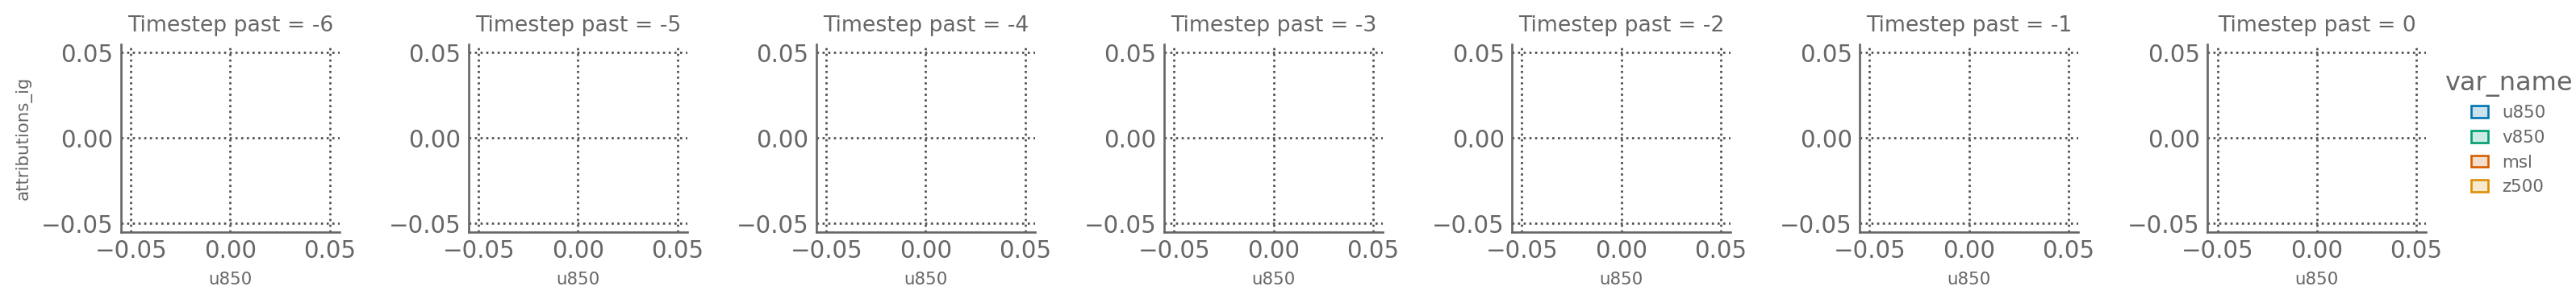

In [78]:
df_ = attributions_per_u850.where(ds_attr.predictions>0.8).mean('time_of_event').to_series().reset_index()

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df_,x='u850', y='attributions_ig', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past')
    .share(y=False)
    .layout(size=(16,2))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    # .limit(x=[95000,None], y=[0,None])
    .label(col='Timestep past =')
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__


In [ ]:
df_ = attributions_per_msl.where(ds_attr.predictions>0.8).mean('time_of_event').to_series().reset_index()

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df_,x='msl', y='attributions_ig', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past')
    .share(y=False)
    .layout(size=(16,2))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[95000,None], y=[0,None])
    .label(col='Timestep past =')
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__


ValueError: Could not interpret value `attributions_ig` for `y`. An entry with this name does not appear in `data`.

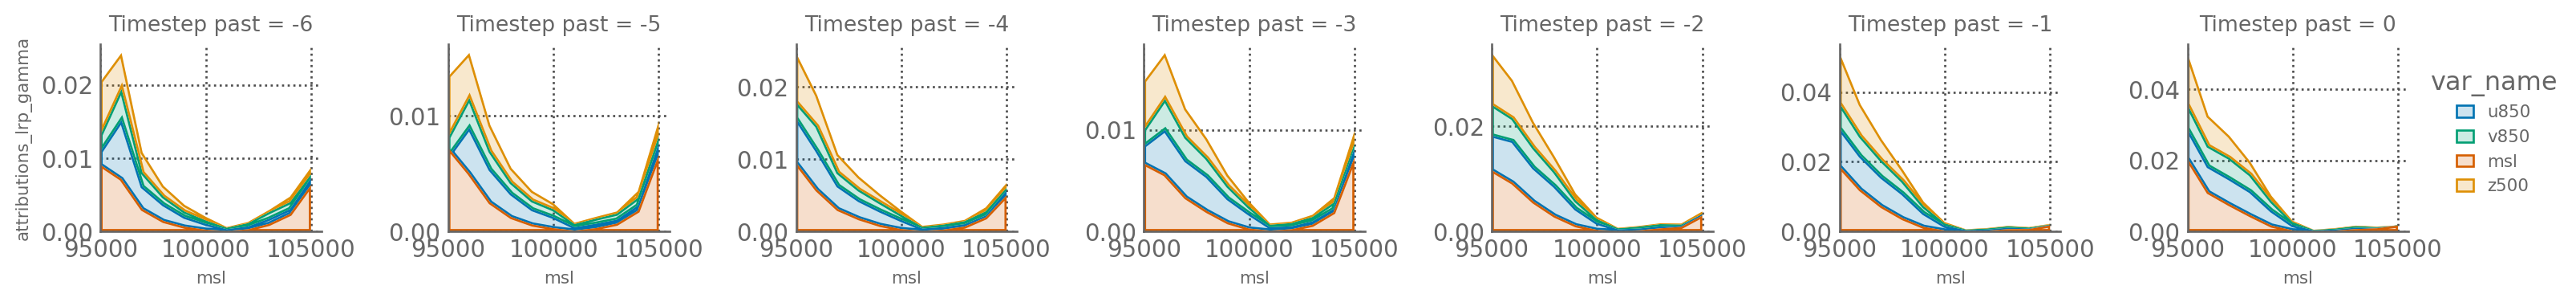

In [82]:
df_ = attributions_per_msl_lrp.where(ds_attr.predictions>0.8).mean('time_of_event').to_series().reset_index()

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df_,x='msl', y='attributions_lrp_gamma', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past')
    .share(y=False)
    .layout(size=(16,2))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[95000,None], y=[0,None])
    .label(col='Timestep past =')
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__


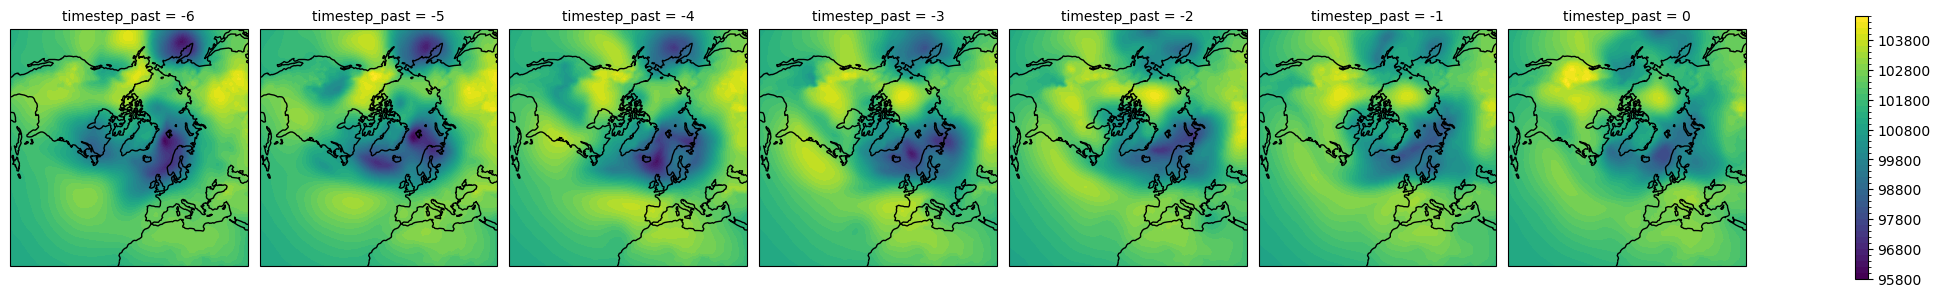

In [266]:
xvind = data_plot.sel(var_name='u850')
yvind = data_plot.sel(var_name='v850')
msl = data_plot.sel(var_name='msl')
msl = msl.where(msl>1000)

plot = msl.sel(time_of_event='2007-01-09').plot.contourf(col='timestep_past',levels=50, subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), transform=ccrs.NorthPolarStereo(0,90))
for ax in plot.axs.flatten():
    ax.coastlines()

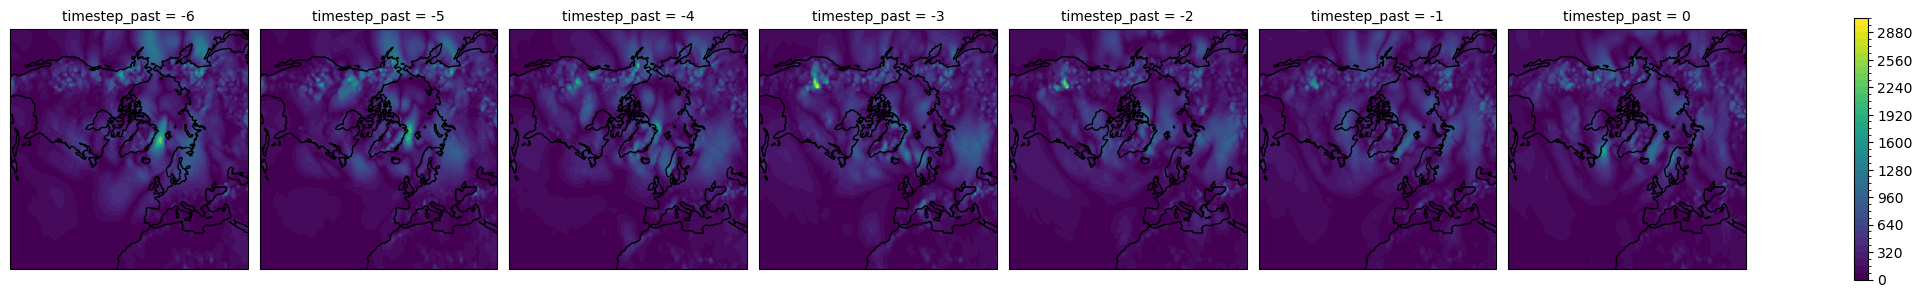

In [265]:
xvind = data_plot.sel(var_name='u850')
yvind = data_plot.sel(var_name='v850')
msl = data_plot.sel(var_name='msl')
msl = msl.where(msl>1000)

plot = (np.abs(msl.diff('x'))+np.abs(msl.diff('x'))).sel(time_of_event='2007-01-09').plot.contourf(col='timestep_past',levels=50, subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), transform=ccrs.NorthPolarStereo(0,90))
for ax in plot.axs.flatten():
    ax.coastlines()


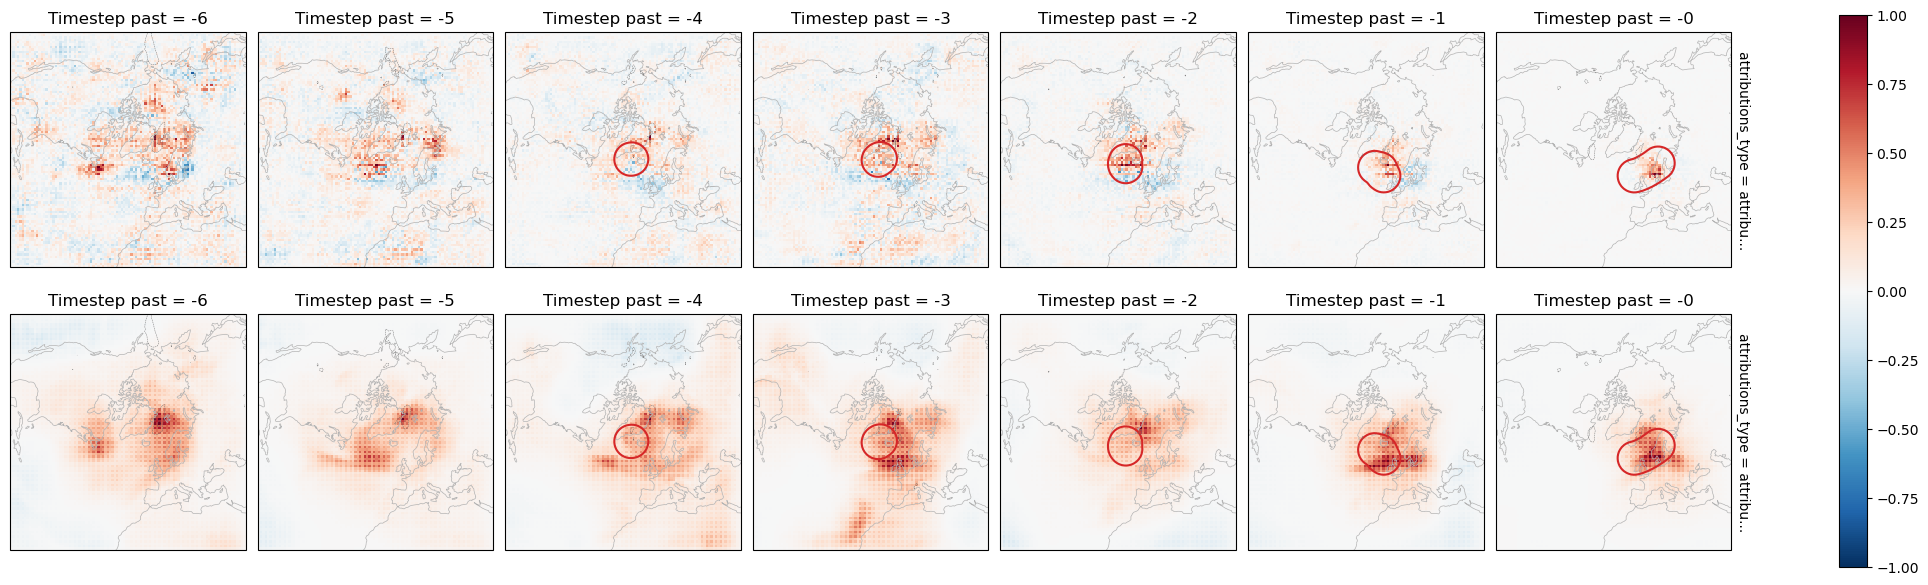

In [261]:
ds_ = ds_attr.sel(time_of_event='2007-01-09').sum('var_name')[['attributions_ig','attributions_lrp_gamma']].to_array('attributions_type').rolling(x=1,y=1, center=True).mean()
ds_ = ds_/ds_.quantile(1,['x','y'])
plot = ds_.plot(col='timestep_past', row='attributions_type', subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), transform=ccrs.NorthPolarStereo(0,90))
for k, ax in enumerate(plot.axs.flatten()):
    dist.sel(time_of_event='2007-01-09').isel(timestep_past=k%7).plot.contour(ax=ax, levels=[1000], colors='C3',  transform=ccrs.NorthPolarStereo(0,90))
    (msl.diff('x')+msl.diff('x')).sel(time_of_event='2007-01-09').isel(timestep_past=k%7).plot.contour(levels=[-3000,-2000,-1000], transform=ccrs.NorthPolarStereo(0,90), colors='.4',linewidths=.3, ax=ax)
    ax.set_title(f'Timestep past = -{6-k%7}')
    ax.coastlines(color='.7', lw=.5)

# 2004-12-31

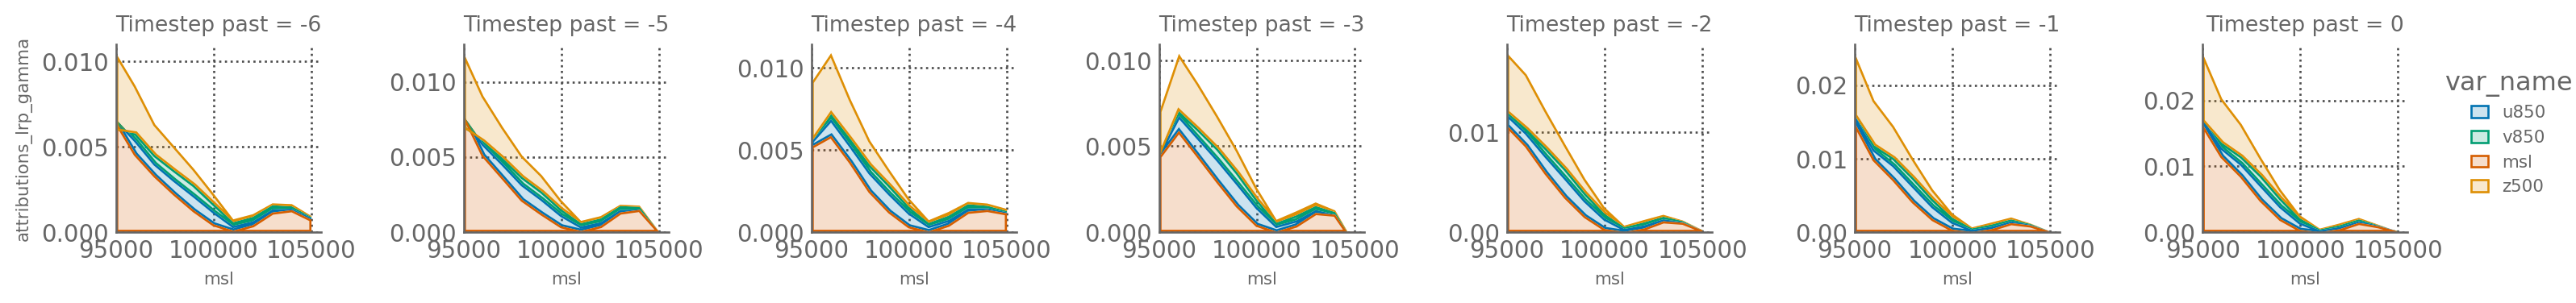

In [242]:
df_ = attributions_per_msl_lrp.where(ds_attr.predictions>0.8).mean('time_of_event').to_series().reset_index()

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df_,x='msl', y='attributions_lrp_gamma', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past')
    .share(y=False)
    .layout(size=(16,2))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[95000,None], y=[0,None])
    .label(col='Timestep past =')
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__


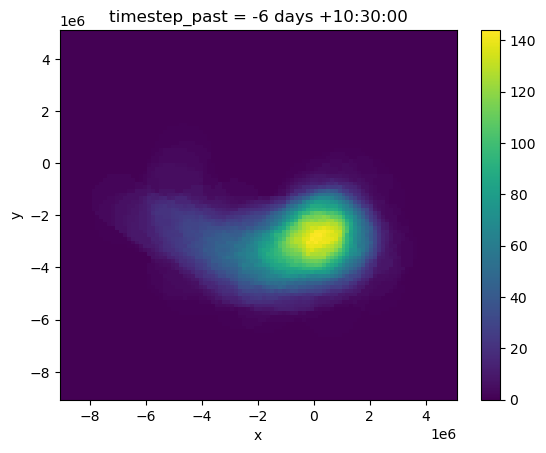

In [64]:
dist.where(dist<1000).bfill('timestep_past').isel(timestep_past=0).count('time_of_event').plot()

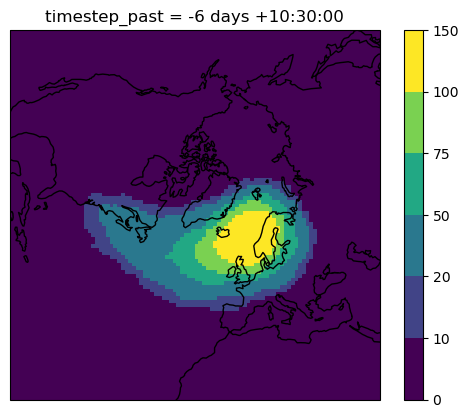

In [71]:
plot= dist.where(dist<1000).bfill('timestep_past').isel(timestep_past=0).count('time_of_event').plot( subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), transform = ccrs.NorthPolarStereo(0,90),levels=[0,10,20,50,75,100,150])
plot.axes.coastlines()

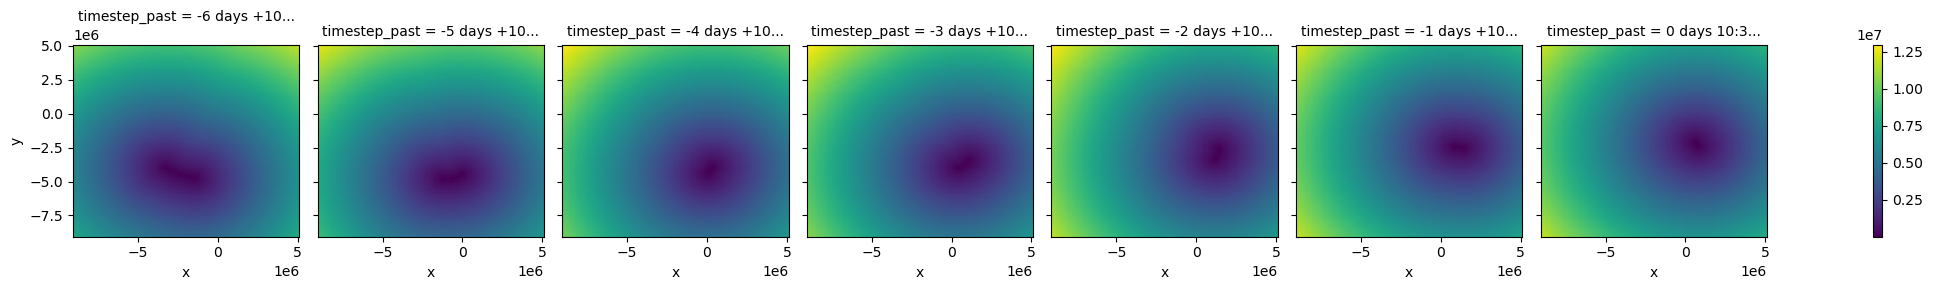

In [36]:
dist.sel(time_of_event='2011-06-22').plot(col='timestep_past')

In [ ]:
dist = distances_to_cyclone.min('track_number').isel(timestep_past=slice(-8*7,None)).coarsen(timestep_past=8).min().reindex(time_of_event=ds_attr.time_of_event).load()

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 100.36 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/array/reductions.py:291: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/array/reductions.py:291: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)


/tmp/ipykernel_373832/1355120910.py:5: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_cycs['x_nps'] = x.drop('lon')
/tmp/ipykernel_373832/1355120910.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_cycs['y_nps'] = y.drop('lat')


In [44]:
df = ds_cycs.sel(time_of_event='2008-07-23', track_number=0).to_dataframe()

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


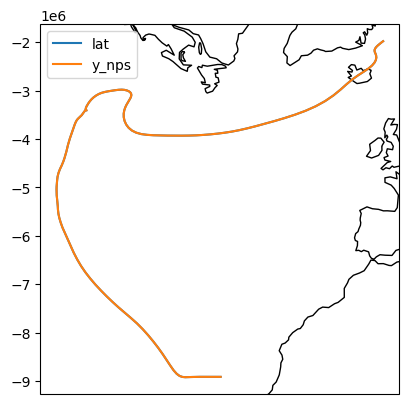

In [46]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.NorthPolarStereo(0,90)))
df.plot(x='lon', y='lat', transform=ccrs.PlateCarree(), ax=ax)
df.plot(x='x_nps', y='y_nps', transform=ccrs.NorthPolarStereo(0,90), ax=ax)
ax.coastlines()

In [9]:
geodetic = ccrs.PlateCarree()  # input CRS (lon/lat in degrees)
north_polar_stereo = ccrs.NorthPolarStereo(0,90)  # output CRS (meters)

# Transform points
x, y = north_polar_stereo.transform_points(geodetic, ds_cycs.lon, ds_cycs.lat)[:, :2].T



ValueError: x and y arrays must be 1 or 2 dimensional